In [14]:
import numpy as np
import pandas as pd
import krippendorff
from irrCAC.raw import CAC
import seaborn as sns

### Consistency Post Processing

In [15]:
SAMPLE_SIZE = 406
df = pd.read_csv(f'../data/consistency_grades_{SAMPLE_SIZE}_sample.csv')
df = df.drop(columns=['Unnamed: 0'])
df['predictions_0'] = pd.Categorical(df['predictions_0'], ['F', 'D-', 'D', 'D+', 'C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+', 'A++'], ordered=True)
df['predictions_1'] = pd.Categorical(df['predictions_1'], ['F', 'D-', 'D', 'D+', 'C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+', 'A++'], ordered=True)
df['predictions_2'] = pd.Categorical(df['predictions_2'], ['F', 'D-', 'D', 'D+', 'C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+', 'A++'], ordered=True)
df['predictions_3'] = pd.Categorical(df['predictions_3'], ['F', 'D-', 'D', 'D+', 'C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+', 'A++'], ordered=True)
df.head()

,assignment_number,query,func_code_string,text,predictions_0,predictions_1,predictions_2,predictions_3
0,297,Waits for setGraphView to finish and then retu...,public static GraphView waitForGraphView() {\n...,Waits for setGraphView to finish and then retu...,A,A,A,A
1,297,Sets the graphViev and marks the work done.\nT...,public static void setGraphView(GraphView newG...,Sets the graphViev and marks the work done.\nT...,A,A,A,A
2,297,Creates the GridPane and 4 charts. Places the ...,@Override\n public void start(Stage stage) ...,Creates the GridPane and 4 charts. Places the ...,NaN,NaN,NaN,NaN
3,297,"Creates the Animal Population line chart, sets...",public void createPopulationLineChart() {\n ...,"Creates the Animal Population line chart, sets...",NaN,NaN,NaN,NaN
4,297,"Creates the Virus line chart, sets up the x,y ...",public void createVirusLineChart() {\n ...,"Creates the Virus line chart, sets up the x,y ...",NaN,NaN,NaN,NaN


In [16]:
df['assignment_number'].unique().shape

(406,)

#### Consistency Calculation per code doc/code pair

In [17]:
def irr_results(df):
    k_df = df[['predictions_0', 'predictions_1', 'predictions_2', 'predictions_3']].copy()
    k_df = k_df.dropna()
    k_df['predictions_0'] = k_df['predictions_0'].cat.codes
    k_df['predictions_1'] = k_df['predictions_1'].cat.codes
    k_df['predictions_2'] = k_df['predictions_2'].cat.codes
    k_df['predictions_3'] = k_df['predictions_3'].cat.codes
    k_df = k_df.transpose()

    cac = CAC(k_df.T, 'ordinal')
    ac2 = cac.gwet()['est']['coefficient_value']

    alpha = krippendorff.alpha(k_df.to_numpy(), level_of_measurement='ordinal')

    return f'Krippendorfs Alpha: {alpha}, Gwet Coefficient: {ac2} for SAMPLE size {SAMPLE_SIZE}'

irr_results(df)


'Krippendorfs Alpha: 1.0, Gwet Coefficient: 1.0 for SAMPLE size 406'

In [18]:
df[(df['predictions_0'] != df['predictions_1']) & (df['predictions_1'] != df['predictions_2']) & (df['predictions_2'] != df['predictions_3'])].dropna()

,assignment_number,query,func_code_string,text,predictions_0,predictions_1,predictions_2,predictions_3


### Project-Level

In [19]:
grades = ['F', 'D-', 'D', 'D+', 'C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+', 'A++']
grade_map = {grade:i for i, grade in enumerate(grades)}
id_map = {i:grade for i, grade in enumerate(grades)}

def average_grade(grades):
    grade_ids = [grade_map[i] for i in list(grades)]
    mean = round(np.mean(grade_ids))
    return id_map[mean]

In [20]:
def consensus(group):
    consensus_dict = {}
    for grade in group:
        if grade not in consensus_dict:
            consensus_dict[grade] = 1
        else:
            consensus_dict[grade] += 1

    return max(consensus_dict, key=consensus_dict.get)

project_df = df.copy()
project_df = project_df.dropna()
project_pred_df = project_df[['assignment_number', 'predictions_0', 'predictions_1', 'predictions_2', 'predictions_3']].groupby('assignment_number').agg(consensus)

if SAMPLE_SIZE == 272:
    project_graded_df = project_df[['assignment_number', 'grade', 'predictions_0', 'predictions_1', 'predictions_2', 'predictions_3']].groupby('assignment_number').agg(consensus)

project_pred_df.head()

,predictions_0,predictions_1,predictions_2,predictions_3
assignment_number,,,,
0,A,A,A,A
1,A,A,A,A
3,A,A,A,A
4,A,A,A,A
5,A,A,A,A


In [21]:
project_pred_df.shape

(406, 4)

In [22]:
irr_results(project_pred_df)

'Krippendorfs Alpha: 1.0, Gwet Coefficient: 1.0 for SAMPLE size 406'

In [23]:
project_pred_df[(project_pred_df['predictions_0'] != project_pred_df['predictions_1']) & (project_pred_df['predictions_1'] != project_pred_df['predictions_2']) & (project_pred_df['predictions_2'] != project_pred_df['predictions_3'])]

,predictions_0,predictions_1,predictions_2,predictions_3
assignment_number,,,,


### Plots

In [24]:
grey = (187/255, 187/255, 187/255)
darkgreen = (51/255, 117/255, 56/255)
teal = (93/255, 168/255, 153/255)
blue = (148/255, 203/255, 236/255)
yellow = (220/255, 205/255, 125/255)
red = (168/255, 96/255, 93/255)
pale_yellow = (164/255, 168/255, 93/255)

#### Ungraded Pairs

In [25]:
ungraded_df = df.copy()
ungraded_df['Graded'] = ungraded_df['predictions_0'].apply(lambda x: 'Ungraded' if x is None else 'Graded')
ungraded_df['Graded'] = ungraded_df['Graded'].fillna('Ungraded')
ungraded_df['assignment_number'].nunique()

406

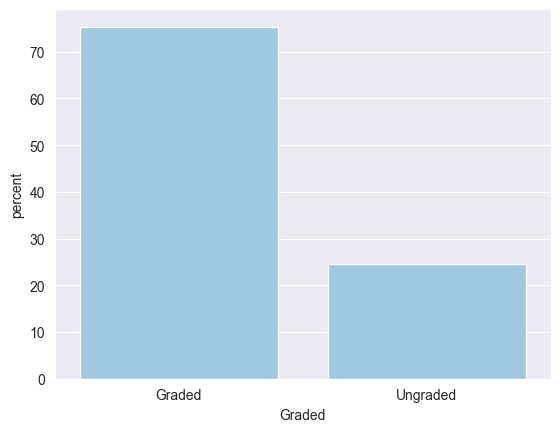

In [26]:
g = sns.countplot(ungraded_df, x='Graded', stat='percent', color=blue)
g.get_figure().savefig(f'plots/ungraded_counts_{SAMPLE_SIZE}.pdf', bbox_inches='tight')

In [15]:
ungraded_df[ungraded_df['Graded'] == 'Ungraded']['text'].apply(lambda x: len(x)).min()
# Max token length of CodeBERT is 512

512

### Function Grade Plot

In [16]:
function_plot_df = df[['assignment_number', 'predictions_0', 'predictions_1', 'predictions_2', 'predictions_3']].copy()
function_plot_df = function_plot_df.melt(id_vars=['assignment_number'], var_name='predictions_i', value_name='grade')
function_plot_df.head()

,assignment_number,predictions_i,grade
0,461,predictions_0,A
1,461,predictions_0,B+
2,461,predictions_0,A-
3,461,predictions_0,A
4,461,predictions_0,A


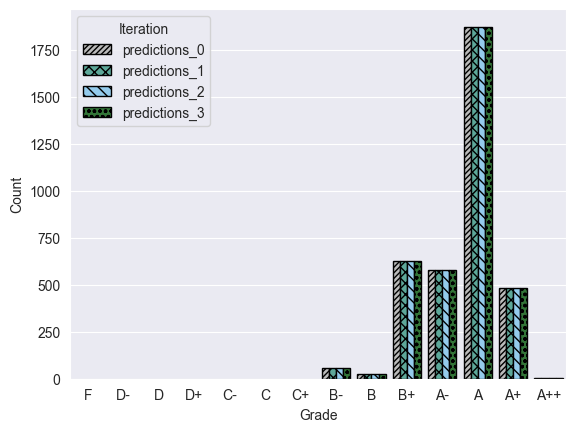

In [17]:
g = sns.countplot(function_plot_df, x='grade', hue='predictions_i', palette=sns.color_palette([blue, darkgreen, teal, blue]))

hatches = ['//', 'x', '\\', 'o']
colors = [grey, teal, blue, darkgreen]
styles = zip(hatches, colors)


for style, these_bars in zip(styles, g.containers):
    for this_bar in these_bars:
        this_bar.set_hatch(3 * style[0])
        this_bar.set_facecolor(style[1])
        this_bar.set_edgecolor('black')

g.set(xlabel='Grade', ylabel='Count')
handles = g.get_legend_handles_labels()[0]

for i in range(len(handles)):
    handles[i].set_facecolor(colors[i])
    handles[i].set_hatch(3 * hatches[i])
    handles[i].set_edgecolor('black')


g.legend(title='Iteration')
g.get_figure().savefig(f'plots/function_grade_counts_{SAMPLE_SIZE}.pdf', bbox_inches='tight')

### Project Grade Plot

In [18]:
project_plot_df = project_pred_df[['predictions_0', 'predictions_1', 'predictions_2', 'predictions_3']].copy().reset_index()
project_plot_df = project_plot_df.melt(id_vars=['assignment_number'], var_name='predictions_i', value_name='grade')
project_plot_df

,assignment_number,predictions_i,grade
0,5,predictions_0,A
1,23,predictions_0,A
2,25,predictions_0,A
3,53,predictions_0,A
4,84,predictions_0,A
...,...,...,...
155,660,predictions_3,A
156,662,predictions_3,A
157,669,predictions_3,A
158,671,predictions_3,A


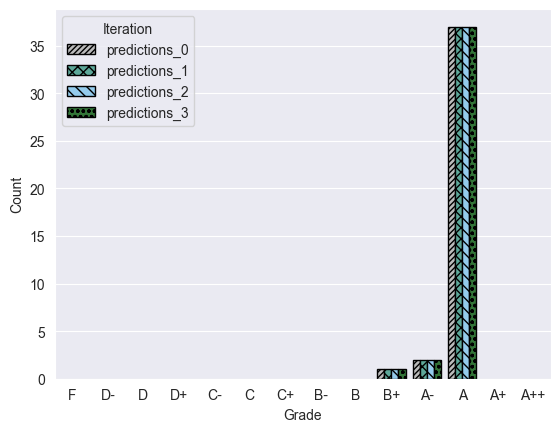

In [19]:
g = sns.countplot(project_plot_df, x='grade', hue='predictions_i',
                  palette=sns.color_palette([blue, darkgreen, teal, blue]))

hatches = ['//', 'x', '\\', 'o']
colors = [grey, teal, blue, darkgreen]
styles = zip(hatches, colors)

for style, these_bars in zip(styles, g.containers):
    for this_bar in these_bars:
        this_bar.set_hatch(3 * style[0])
        this_bar.set_facecolor(style[1])
        this_bar.set_edgecolor('black')

g.set(xlabel='Grade', ylabel='Count')
handles = g.get_legend_handles_labels()[0]

for i in range(len(handles)):
    handles[i].set_facecolor(colors[i])
    handles[i].set_hatch(3 * hatches[i])
    handles[i].set_edgecolor('black')

g.legend(title='Iteration')
g.get_figure().savefig(f'plots/project_grade_counts_{SAMPLE_SIZE}.pdf', bbox_inches='tight')

### Graded Accuracy

In [20]:
from metrics import accuracy

if SAMPLE_SIZE == 272:
    project_graded_df['grade'] = pd.Categorical(project_graded_df['grade'], ['F', 'D-', 'D', 'D+', 'C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+', 'A++'], ordered=True)
    project_graded_df['predictions_0'] = pd.Categorical(project_graded_df['predictions_0'], ['F', 'D-', 'D', 'D+', 'C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+', 'A++'], ordered=True)
    project_graded_df['grade'] = project_graded_df['grade'].cat.codes
    project_graded_df['predictions_0'] = project_graded_df['predictions_0'].cat.codes

    label = project_graded_df['grade'].to_list()
    pred = project_graded_df['predictions_0'].to_list()
    accuracy_res = accuracy.compute(predictions=pred, references=label)['accuracy']
    accuracy_res

Using the latest cached version of the module from /Users/marcus/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--f1/34c46321f42186df33a6260966e34a368f14868d9cc2ba47d142112e2800d233 (last modified on Tue Jan 21 11:11:48 2025) since it couldn't be found locally at evaluate-metric--f1, or remotely on the Hugging Face Hub.
Using the latest cached version of the module from /Users/marcus/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--accuracy/f887c0aab52c2d38e1f8a215681126379eca617f96c447638f751434e8e65b14 (last modified on Mon Oct  9 16:43:38 2023) since it couldn't be found locally at evaluate-metric--accuracy, or remotely on the Hugging Face Hub.
Using the latest cached version of the module from /Users/marcus/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--recall/11f90e583db35601050aed380d48e83202a896976b9608432fba9244fb447f24 (last modified on Tue Jan 21 11:11:49 2025) since it couldn't be found locally at evaluate-metric-